### 0. Requirements

run once

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
pip install pandas numpy matplotlib seaborn scikit-learn torch torchvision torchaudio transformers datasets accelerate tqdm nltk

### 1. Importing necessary libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
from sklearn.metrics import roc_curve, auc, precision_recall_curve

import torch
import os
import string
import re
from torch.utils.data import Dataset, DataLoader

from transformers import (
    Trainer,
    TrainingArguments,
    AutoTokenizer,
    AutoConfig,
    AutoModelForSequenceClassification
)

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

# Ensuring required NLTK components are available
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')

# Use ALBERT as the base encoder for classification
MODEL_NAME = "albert-base-v2"
print(f"Model: {MODEL_NAME}")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


Model: albert-base-v2


In [5]:
TEST_SIZE = 0.2

In [4]:
def get_device_and_config():
    config = {}

    # CUDA GPU
    if torch.cuda.is_available():
        device = torch.device("cuda")
        backend = "CUDA GPU"

        config.update({
            "per_device_train_batch_size": 32,
            "per_device_eval_batch_size": 32,
            "fp16": True,
            "gradient_accumulation_steps": 1
        })

    # Apple Silicon (MPS)
    elif torch.backends.mps.is_available():
        device = torch.device("mps")
        backend = "Apple Silicon (MPS)"

        config.update({
            "per_device_train_batch_size": 16,
            "per_device_eval_batch_size": 16,
            "fp16": False,   # unstable on MPS
            "gradient_accumulation_steps": 1
        })

    # CPU fallback
    else:
        device = torch.device("cpu")
        backend = "CPU"

        config.update({
            "per_device_train_batch_size": 8,
            "per_device_eval_batch_size": 8,
            "fp16": False,
            "gradient_accumulation_steps": 2
        })

    return device, backend, config


device, backend, perf_config = get_device_and_config()
print(f"Device detected: {backend}")
print("Auto performance config:", perf_config)

Device detected: CUDA GPU
Auto performance config: {'per_device_train_batch_size': 32, 'per_device_eval_batch_size': 32, 'fp16': True, 'gradient_accumulation_steps': 1}


### 2. Read the dataset

In [8]:
# df = pd.read_csv("combined_ai_human.csv")
df = pd.read_csv("/content/drive/MyDrive/minor prj temp/updated_combined_ai_human.csv")
df.head()


,text,generated
0,The 2013 film 12 Years a Slave proved that sla...,0
1,Social Media Examiner’s (2021) video on social...,0
2,The world has been shattered by Russia’s attac...,0
3,Table of Contents\n 1. Facts\n 2. Issue\n 3. H...,0
4,Charles Schwab is a for-profit Corporation who...,0


In [9]:
print(df.info())
print(df['generated'].value_counts())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 63464 entries, 0 to 63463
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   text       63464 non-null  object
 1   generated  63464 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 991.8+ KB
None
generated
0    31732
1    31732
Name: count, dtype: int64


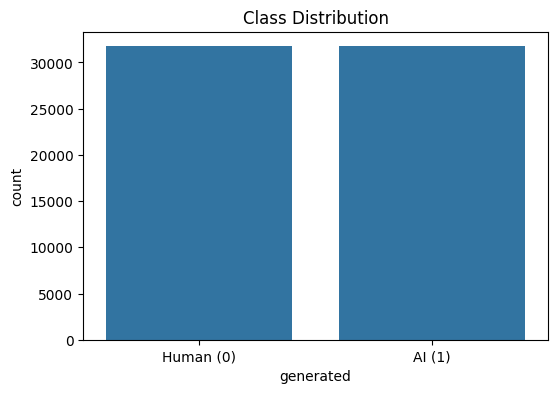

In [10]:
plt.figure(figsize=(6,4))
sns.countplot(x='generated', data=df)
plt.xticks([0,1], ['Human (0)', 'AI (1)'])
plt.title("Class Distribution")
plt.show()


### 3. Text length Analysis

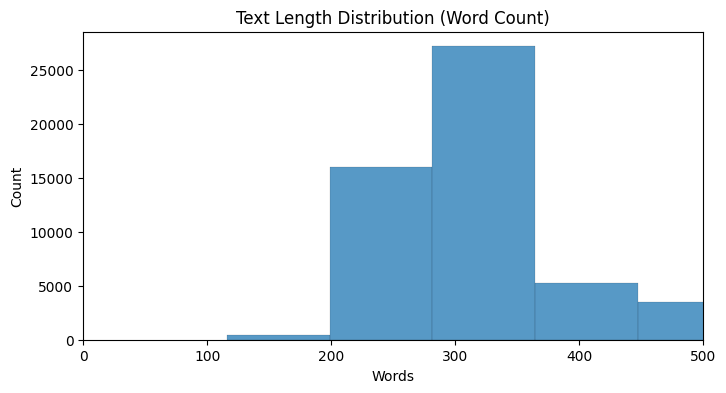

In [11]:
df['text_length'] = df['text'].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(8,4))
sns.histplot(df['text_length'], bins=500)
plt.title("Text Length Distribution (Word Count)")
plt.xlabel("Words")
plt.xlim(0,500)
plt.show()


### Cleaning text

In [12]:
def clean_text(text):
    """
    Cleans the input text by performing several operations:
    - Convert to lowercase to maintain uniformity.
    - Remove punctuation to reduce noise.
    - Remove numbers as they may not contribute to text classification in this context.
    - Strip extra spaces for clean, standardized input.
    - Remove stopwords to focus on the meaningful words.

    Parameters:
    text (str): The input text to be cleaned.

    Returns:
    str: The cleaned text.
    """
    # Convert text to lowercase
    text = text.lower()
    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))
    # Remove numbers
    text = re.sub(r'\d+', '', text)
    # Remove extra spaces
    text = text.strip()
    # Remove stopwords
    stop_words = set(stopwords.words('english'))
    tokens = word_tokenize(text)
    filtered_tokens = [word for word in tokens if word not in stop_words]
    text = ' '.join(filtered_tokens)
    return text

In [13]:
# Cleaning the text column in the downsized dataframe
df['text'] = df['text'].apply(clean_text)
df['text'] = df['text'].fillna("")  # Replacing NaN with empty strings

In [15]:
df

,text,generated,text_length
0,film years slave proved slavery worldwide issu...,0,401
1,social media examiner ’ video social media ini...,0,212
2,world shattered russia ’ attack ukraine past d...,0,191
3,table contents facts issue holding reasoning r...,0,219
4,charles schwab forprofit corporation whose mai...,0,204
...,...,...,...
63459,uncommon students choose enjoy summer free lea...,0,425
63460,projects another way fun learning something ne...,0,209
63461,school year students continually asked complet...,0,236
63462,students education ongoing process easily disr...,0,312


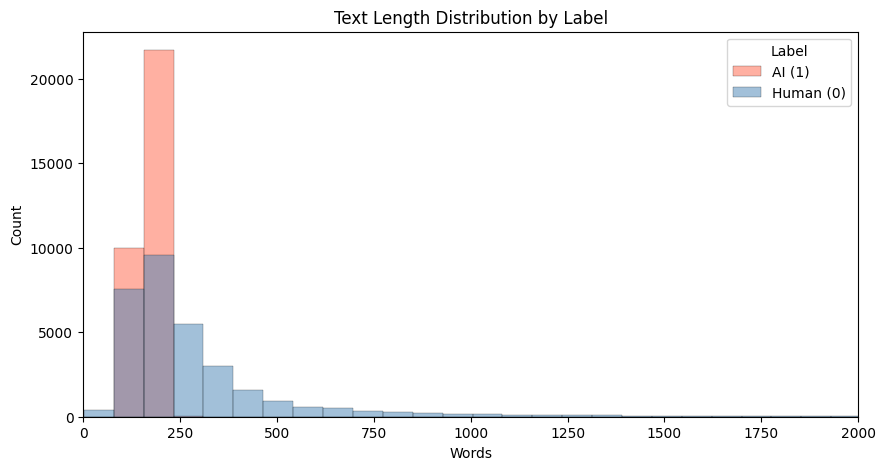

In [17]:
df['text_length'] = df['text'].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(10,5))
sns.histplot(
    data=df,
    x='text_length',
    hue='generated',
    bins=300,
    palette={0: 'steelblue', 1: 'tomato'}
)
plt.title("Text Length Distribution by Label")
plt.xlabel("Words")
plt.xlim(0, 2000)
plt.legend(title='Label', labels=['AI (1)', 'Human (0)'])
plt.show()

In [27]:
import random

def random_truncate_words(text, min_words=150, max_words=230):
    words = str(text).split()
    target = random.randint(min_words, max_words)
    return ' '.join(words[:target])

df['text'] = df['text'].apply(random_truncate_words)

# Verify the distribution looks right
df['text_length'] = df['text'].apply(lambda x: len(str(x).split()))
print(df.groupby('generated')['text_length'].describe())

             count        mean        std   min    25%    50%    75%    max
generated                                                                  
0          31732.0  168.858471  36.415349   2.0  151.0  172.0  196.0  230.0
1          31732.0  162.093281  24.096591  82.0  144.0  166.0  181.0  229.0


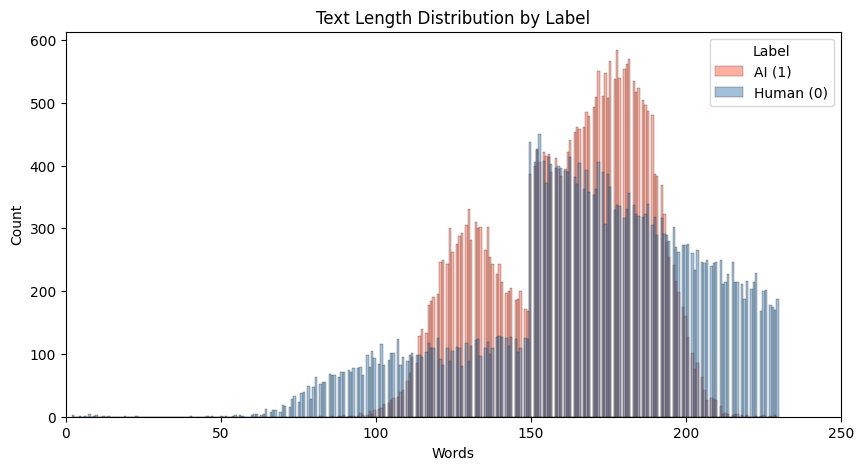

In [28]:
df['text_length'] = df['text'].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(10,5))
sns.histplot(
    data=df,
    x='text_length',
    hue='generated',
    bins=300,
    palette={0: 'steelblue', 1: 'tomato'}
)
plt.title("Text Length Distribution by Label")
plt.xlabel("Words")
plt.xlim(0, 250)
plt.legend(title='Label', labels=['AI (1)', 'Human (0)'])
plt.show()

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/minor prj temp/use_this_df_processed.csv")

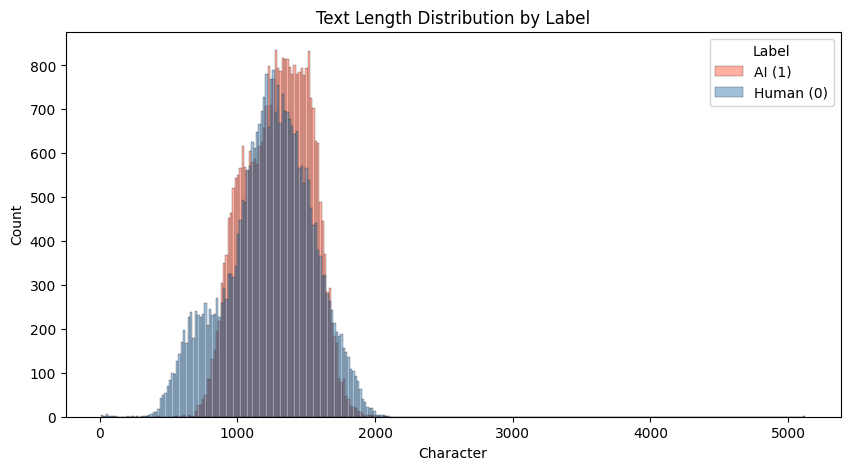

In [30]:
df['text_length_str'] = df['text'].apply(lambda x: len(str(x)))

plt.figure(figsize=(10,5))
sns.histplot(
    data=df,
    x='text_length_str',
    hue='generated',
    bins=300,
    palette={0: 'steelblue', 1: 'tomato'}
)
plt.title("Text Length Distribution by Label")
plt.xlabel("Character")
# plt.xlim(0, 1000)
plt.legend(title='Label', labels=['AI (1)', 'Human (0)'])
plt.show()

In [ ]:
# df_generated_0 = df[df["generated"] == 0]
# df_generated_1 = df[df["generated"] == 1]
# df_generated_0.to_csv("/content/drive/MyDrive/minor prj temp/generated_0.csv", index=False)
# df_generated_1.to_csv("/content/drive/MyDrive/minor prj temp/generated_1.csv", index=False)

# df.to_csv("/content/drive/MyDrive/minor prj temp/text_balanced.csv", index=False)

In [19]:
# df_0 = pd.read_csv("/content/drive/MyDrive/minor prj temp/generated_0.csv")
# df_1 = pd.read_csv("/content/drive/MyDrive/minor prj temp/generated_1.csv")


In [20]:
# combined_df = pd.concat([df_0, df_1], ignore_index=True)

In [29]:
# df.to_csv("/content/drive/MyDrive/minor prj temp/use_this_df_processed.csv", index=False)

### 4. Train and Validation splitting

In [31]:
train_texts, val_texts, train_labels, val_labels = train_test_split(
    df['text'],
    df['generated'],
    test_size=TEST_SIZE,
    stratify=df['generated'], # keeps the proportion same
    random_state=42
)


checking data

In [32]:
print("Total samples:", len(df))
print("Unique texts:", df["text"].nunique())

Total samples: 63464
Unique texts: 62462


In [33]:
train_set = set(train_texts)
val_set = set(val_texts)

print("Overlap:", len(train_set.intersection(val_set)))

Overlap: 320


In [34]:
df["word_count"] = df["text"].str.split().map(len)
print(df.groupby("generated")["word_count"].describe())

             count        mean        std   min    25%    50%    75%    max
generated                                                                  
0          31732.0  168.858471  36.415349   2.0  151.0  172.0  196.0  230.0
1          31732.0  162.093281  24.096591  82.0  144.0  166.0  181.0  229.0


In [35]:
from sklearn.linear_model import LogisticRegression

X = df["text"].str.split().map(len).values.reshape(-1, 1)
y = df["generated"]

clf = LogisticRegression().fit(X, y)
print(clf.score(X, y))

0.532191478633556


In [ ]:
df[df["generated"] == 1]["text"].str.contains("AI language model").mean()

np.float64(0.0)

### 5. Loading tokenizer

In [36]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/684 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/760k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

### 6. Tokenize the text column

In [37]:
train_encodings = tokenizer(
    list(train_texts),
    truncation=True, # cuts long texts
    padding=True, # equal sequence length
    max_length=350
)

val_encodings = tokenizer(
    list(val_texts),
    truncation=True,
    padding=True,
    max_length=350
)


testing dataset

In [38]:
train_token_lengths = [sum(att) for att in train_encodings["attention_mask"]]
val_token_lengths = [sum(att) for att in val_encodings["attention_mask"]]

print("Train token length stats")
print(np.mean(train_token_lengths), np.min(train_token_lengths), np.max(train_token_lengths))

print("Validation token length stats")
print(np.mean(val_token_lengths), np.min(val_token_lengths), np.max(val_token_lengths))

Train token length stats
195.39959819582046 5 350
Validation token length stats
195.438509414638 4 350


In [39]:
train_df_split = pd.DataFrame({
    "label": train_labels,
    "token_len": train_token_lengths
})

print(train_df_split.groupby("label")["token_len"].describe())

         count        mean        std    min    25%    50%    75%    max
label                                                                   
0      25385.0  194.576364  44.691735    5.0  170.0  197.0  226.0  350.0
1      25386.0  196.222800  32.493507  103.0  173.0  199.0  219.0  350.0


In [40]:
from sklearn.linear_model import LogisticRegression

X = np.array(train_token_lengths).reshape(-1, 1)
y = train_labels.values

clf = LogisticRegression().fit(X, y)

val_token_lengths = [sum(att) for att in val_encodings["attention_mask"]]
print("Length-only validation accuracy:",
      clf.score(np.array(val_token_lengths).reshape(-1, 1), val_labels.values))

Length-only validation accuracy: 0.5191050185141417


In [41]:
import hashlib

def hash_text(t):
    return hashlib.md5(t.strip().encode()).hexdigest()

train_hashes = set(train_texts.map(hash_text))
val_hashes = set(val_texts.map(hash_text))

print("Exact hash overlap:", len(train_hashes.intersection(val_hashes)))

Exact hash overlap: 320


In [42]:
df.groupby("text")["generated"].nunique().value_counts()

,count
generated,
1,62462


removing duplicated and retying to check for duplicates or leakage

In [43]:
df = df.drop_duplicates(subset="text").reset_index(drop=True)

In [44]:
print(df.groupby("generated")["word_count"].describe())

             count        mean        std   min    25%    50%    75%    max
generated                                                                  
0          30730.0  169.671103  36.318612   2.0  152.0  172.0  196.0  230.0
1          31732.0  162.093281  24.096591  82.0  144.0  166.0  181.0  229.0


In [45]:
min_count = min(len(df[df['generated']==0]), len(df[df['generated']==1]))

df_balanced = pd.concat([
    df[df['generated']==0].sample(min_count, random_state=42),
    df[df['generated']==1].sample(min_count, random_state=42)
]).sample(frac=1, random_state=42).reset_index(drop=True)

print(df_balanced['generated'].value_counts())

generated
1    30730
0    30730
Name: count, dtype: int64


In [46]:
train_texts, val_texts, train_labels, val_labels = train_test_split(
    df["text"],
    df["generated"],
    test_size=TEST_SIZE,
    stratify=df["generated"],
    random_state=42
)

In [47]:
train_set = set(train_texts)
val_set = set(val_texts)
print("Overlap:", len(train_set.intersection(val_set)))

Overlap: 0


In [48]:
train_encodings = tokenizer(
    list(train_texts),
    truncation=True, # cuts long texts
    padding=True, # equal sequence length
    max_length=350 # max length is 300 as previously done in preprocessing
)

val_encodings = tokenizer(
    list(val_texts),
    truncation=True,
    padding=True,
    max_length=350
)

### 7. Custom pytorch dataset
This wraps tokenized data into a format Hugging Face Trainer understands.

In [49]:
class TextDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels.iloc[idx])
        return item

    def __len__(self):
        return len(self.labels)


### 8. Create Dataset Objects
Creates training and validation datasets for the model.

In [50]:
train_dataset = TextDataset(train_encodings, train_labels)
val_dataset = TextDataset(val_encodings, val_labels)


### 9. Load classification model

In [51]:
config = AutoConfig.from_pretrained(MODEL_NAME)
config.num_labels = 2

# Different transformer backbones expose different dropout attribute names.
for attr in ('dropout', 'seq_classif_dropout', 'hidden_dropout_prob',
             'attention_dropout', 'attention_probs_dropout_prob',
             'classifier_dropout_prob'):
    if hasattr(config, attr):
        setattr(config, attr, 0.3)

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    config=config
)
model.to(device)
print(model.config)

model.safetensors:   0%|          | 0.00/47.4M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/25 [00:00<?, ?it/s]

AlbertForSequenceClassification LOAD REPORT from: albert-base-v2
Key                          | Status     | 
-----------------------------+------------+-
predictions.dense.bias       | UNEXPECTED | 
predictions.LayerNorm.bias   | UNEXPECTED | 
predictions.dense.weight     | UNEXPECTED | 
predictions.bias             | UNEXPECTED | 
predictions.decoder.bias     | UNEXPECTED | 
predictions.LayerNorm.weight | UNEXPECTED | 
classifier.weight            | MISSING    | 
classifier.bias              | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


AlbertConfig {
  "architectures": [
    "AlbertForMaskedLM"
  ],
  "attention_probs_dropout_prob": 0.3,
  "bos_token_id": 2,
  "classifier_dropout_prob": 0.3,
  "down_scale_factor": 1,
  "dtype": "float32",
  "embedding_size": 128,
  "eos_token_id": 3,
  "gap_size": 0,
  "hidden_act": "gelu_new",
  "hidden_dropout_prob": 0.3,
  "hidden_size": 768,
  "initializer_range": 0.02,
  "inner_group_num": 1,
  "intermediate_size": 3072,
  "layer_norm_eps": 1e-12,
  "max_position_embeddings": 512,
  "model_type": "albert",
  "net_structure_type": 0,
  "num_attention_heads": 12,
  "num_hidden_groups": 1,
  "num_hidden_layers": 12,
  "num_memory_blocks": 0,
  "pad_token_id": 0,
  "tie_word_embeddings": true,
  "transformers_version": "5.0.0",
  "type_vocab_size": 2,
  "vocab_size": 30000
}



In [ ]:
# config = AutoConfig.from_pretrained(MODEL_NAME)
# config.hidden_dropout_prob = 0.4
# config.attention_probs_dropout_prob = 0.4
# config.num_labels = 2  # set number of labels here

# model = AutoModelForSequenceClassification.from_pretrained(
#     MODEL_NAME,
#     config=config
# )

# model.to(device)


### 10. Training Arguments

In [52]:
training_args = TrainingArguments(
    output_dir="./results",

    eval_strategy="epoch",
    save_strategy="epoch",

    learning_rate=2e-5,
    num_train_epochs=3,
    weight_decay=0.05,

    logging_dir="./logs",
    logging_steps=100,

    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,

    report_to="none",

    # Auto-detected performance settings
    per_device_train_batch_size=perf_config["per_device_train_batch_size"],
    per_device_eval_batch_size=perf_config["per_device_eval_batch_size"],
    fp16=perf_config["fp16"],
    gradient_accumulation_steps=perf_config["gradient_accumulation_steps"],
)


`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [53]:
model.to(device)

AlbertForSequenceClassification(
  (albert): AlbertModel(
    (embeddings): AlbertEmbeddings(
      (word_embeddings): Embedding(30000, 128, padding_idx=0)
      (position_embeddings): Embedding(512, 128)
      (token_type_embeddings): Embedding(2, 128)
      (LayerNorm): LayerNorm((128,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.3, inplace=False)
    )
    (encoder): AlbertTransformer(
      (embedding_hidden_mapping_in): Linear(in_features=128, out_features=768, bias=True)
      (albert_layer_groups): ModuleList(
        (0): AlbertLayerGroup(
          (albert_layers): ModuleList(
            (0): AlbertLayer(
              (full_layer_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
              (attention): AlbertAttention(
                (attention_dropout): Dropout(p=0.3, inplace=False)
                (output_dropout): Dropout(p=0.3, inplace=False)
                (query): Linear(in_features=768, out_features=768, bias=True)
         

### 11. Define trainer
Hugging Face Trainer handles: training loop, evaluation and checkpointing

In [54]:
# Shows precision, recall, F1-score
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=1)

    acc = accuracy_score(labels, predictions)
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, predictions, average="binary"
    )

    return {
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

In [55]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics
)


### 12. Train the model

In [56]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.135943,0.068071,0.983351,0.979235,0.988183,0.983689
2,0.059493,0.097309,0.979909,0.966626,0.994801,0.980511
3,0.049676,0.133034,0.977427,0.960097,0.997006,0.978204


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['albert.embeddings.LayerNorm.weight', 'albert.embeddings.LayerNorm.bias', 'albert.encoder.albert_layer_groups.0.albert_layers.0.attention.LayerNorm.weight', 'albert.encoder.albert_layer_groups.0.albert_layers.0.attention.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['albert.embeddings.LayerNorm.beta', 'albert.embeddings.LayerNorm.gamma', 'albert.encoder.albert_layer_groups.0.albert_layers.0.attention.LayerNorm.beta', 'albert.encoder.albert_layer_groups.0.albert_layers.0.attention.LayerNorm.gamma'].


TrainOutput(global_step=4686, training_loss=0.1259115214435351, metrics={'train_runtime': 4013.3617, 'train_samples_per_second': 37.352, 'train_steps_per_second': 1.168, 'total_flos': 2448969646851000.0, 'train_loss': 0.1259115214435351, 'epoch': 3.0})

### 13. Evaluation

In [57]:
preds = trainer.predict(val_dataset)
y_pred = np.argmax(preds.predictions, axis=1)

print(classification_report(val_labels, y_pred, digits=6))

# Converts logits → class predictions

              precision    recall  f1-score   support

           0   0.987681  0.978360  0.982998      6146
           1   0.979235  0.988183  0.983689      6347

    accuracy                       0.983351     12493
   macro avg   0.983458  0.983272  0.983344     12493
weighted avg   0.983390  0.983351  0.983349     12493



In [58]:
eval_results = trainer.evaluate()
print(eval_results)

{'eval_loss': 0.06803568452596664, 'eval_accuracy': 0.9833506763787722, 'eval_precision': 0.9792349726775956, 'eval_recall': 0.988183393729321, 'eval_f1': 0.9836888331242158, 'eval_runtime': 110.6646, 'eval_samples_per_second': 112.891, 'eval_steps_per_second': 3.533, 'epoch': 3.0}


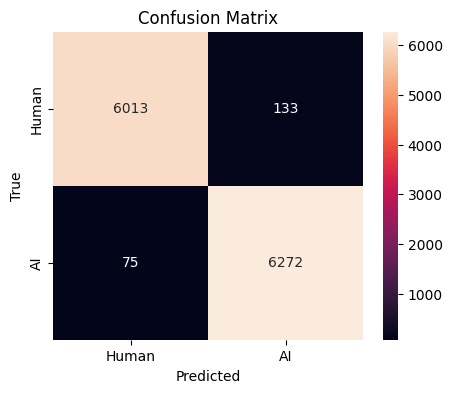

In [59]:
cm = confusion_matrix(val_labels, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=["Human", "AI"],
            yticklabels=["Human", "AI"])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()


### 14. Saving the model


In [60]:
save_dir = "/content/drive/MyDrive/training/" + MODEL_NAME.replace('/', '_') + "_80_20_0.05wd_2lr_3epoch"
trainer.save_model(save_dir)
tokenizer.save_pretrained(save_dir)
print(f"Saved to {save_dir}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved to /content/drive/MyDrive/training/albert-base-v2_80_20_0.05wd_2lr_3epoch


In [ ]:
# trainer.save_model("./albert_ai_human_detector_lr1_do4_wd_0pt09")
# tokenizer.save_pretrained("./albert_ai_human_detector_lr1_do4_wd_0pt09")


### 15. Extra

In [61]:
# Extract trainer logs
logs = trainer.state.log_history

history = pd.DataFrame(logs)
history.head()


,loss,grad_norm,learning_rate,epoch,step,eval_loss,eval_accuracy,eval_precision,eval_recall,eval_f1,eval_runtime,eval_samples_per_second,eval_steps_per_second,train_runtime,train_samples_per_second,train_steps_per_second,total_flos,train_loss
0,0.705879,28.181484,0.000020,0.064020,100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0.556560,10.157547,0.000019,0.128041,200,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0.362545,14.031607,0.000019,0.192061,300,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,0.325063,32.743496,0.000018,0.256082,400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0.243494,22.607666,0.000018,0.320102,500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


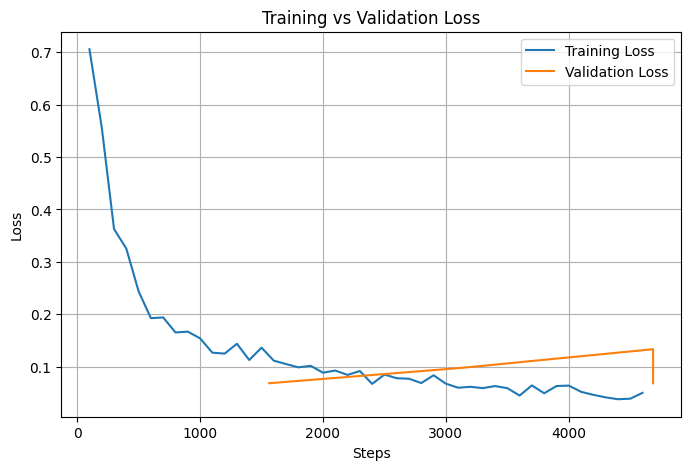

In [62]:
logs = trainer.state.log_history
history = pd.DataFrame(logs)

train_loss = history.dropna(subset=["loss"])[["step", "loss"]]
eval_loss  = history.dropna(subset=["eval_loss"])[["step", "epoch", "eval_loss",
                                                     "eval_accuracy", "eval_f1",
                                                     "eval_precision", "eval_recall"]]

plt.figure(figsize=(8,5))
plt.plot(train_loss["step"], train_loss["loss"], label="Training Loss")
plt.plot(eval_loss["step"],  eval_loss["eval_loss"],  label="Validation Loss")
plt.title("Training vs Validation Loss")
plt.xlabel("Steps"); plt.ylabel("Loss"); plt.legend(); plt.grid(); plt.show()

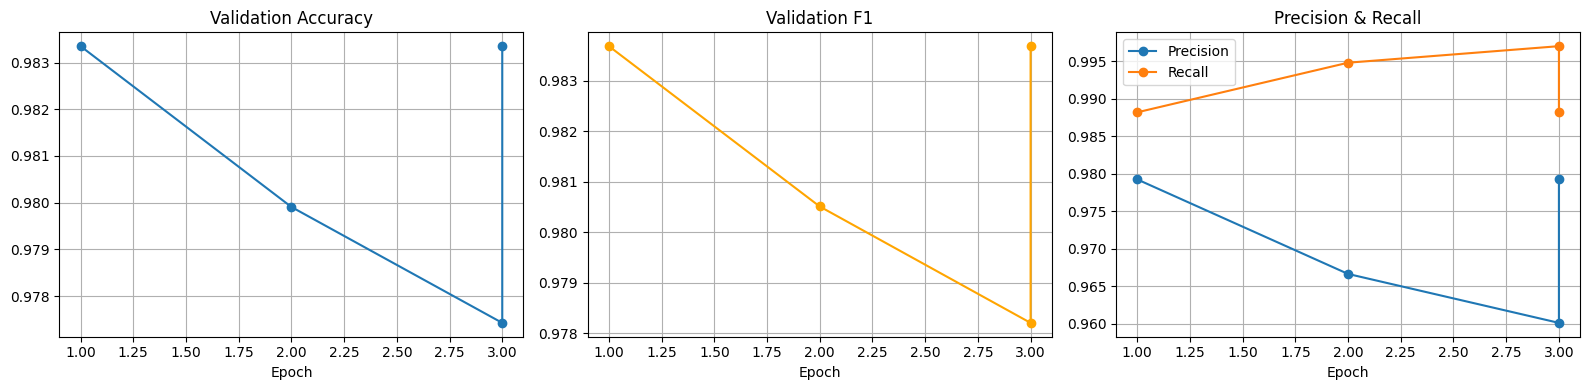

In [63]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(eval_loss["epoch"], eval_loss["eval_accuracy"], marker='o')
axes[0].set_title("Validation Accuracy"); axes[0].set_xlabel("Epoch"); axes[0].grid()

axes[1].plot(eval_loss["epoch"], eval_loss["eval_f1"], marker='o', color='orange')
axes[1].set_title("Validation F1"); axes[1].set_xlabel("Epoch"); axes[1].grid()

axes[2].plot(eval_loss["epoch"], eval_loss["eval_precision"], marker='o', label="Precision")
axes[2].plot(eval_loss["epoch"], eval_loss["eval_recall"],    marker='o', label="Recall")
axes[2].set_title("Precision & Recall"); axes[2].set_xlabel("Epoch")
axes[2].legend(); axes[2].grid()

plt.tight_layout(); plt.show()

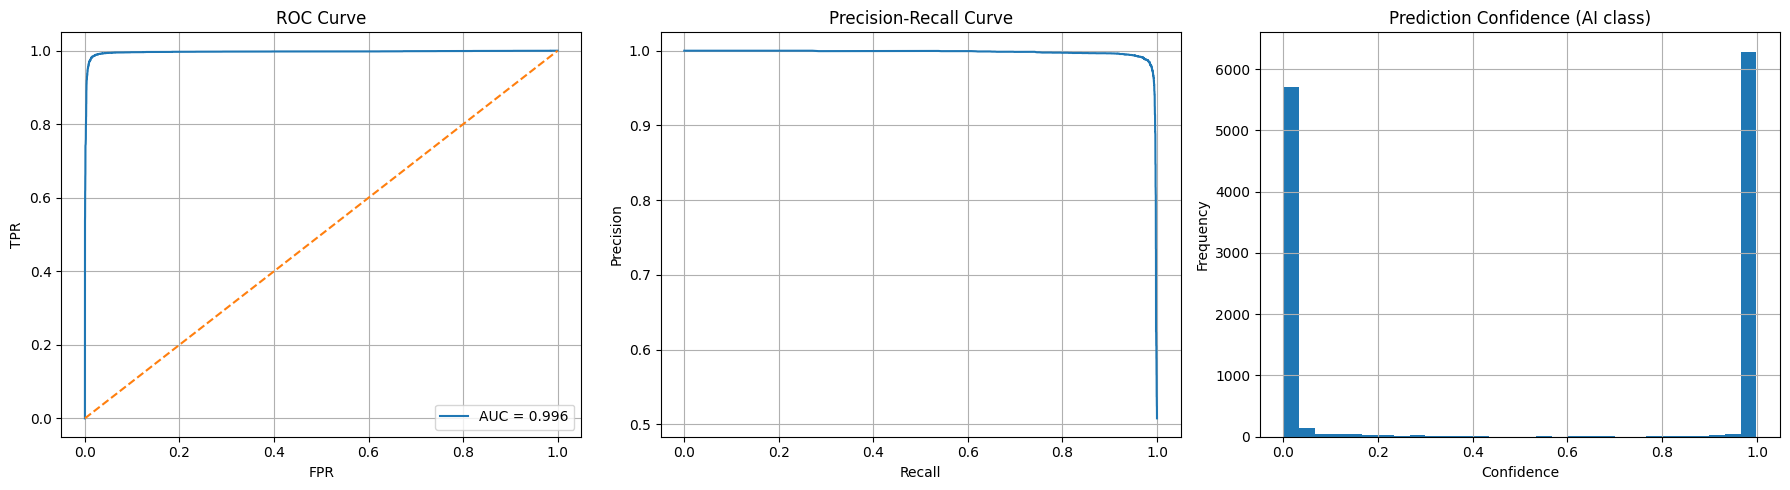

In [64]:

probs = torch.softmax(torch.tensor(preds.predictions), dim=1)[:,1]

# ROC
fpr, tpr, _ = roc_curve(val_labels, probs)
roc_auc = auc(fpr, tpr)

# PR
precision_curve, recall_curve, _ = precision_recall_curve(val_labels, probs)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
axes[0].plot([0,1],[0,1], linestyle='--')
axes[0].set_title("ROC Curve"); axes[0].set_xlabel("FPR"); axes[0].set_ylabel("TPR")
axes[0].legend(); axes[0].grid()

axes[1].plot(recall_curve, precision_curve)
axes[1].set_title("Precision-Recall Curve"); axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision"); axes[1].grid()

axes[2].hist(probs.numpy(), bins=30)
axes[2].set_title("Prediction Confidence (AI class)")
axes[2].set_xlabel("Confidence"); axes[2].set_ylabel("Frequency"); axes[2].grid()

plt.tight_layout(); plt.show()

Old codes

In [ ]:
# Extract trainer logs
logs = trainer.state.log_history

history = pd.DataFrame(logs)

# Separate train and eval logs cleanly
train_history = history.dropna(subset=["loss"]).reset_index(drop=True)
eval_history = history.dropna(subset=["eval_loss"]).reset_index(drop=True)

print("Training logs:")
display(train_history.head())
print("Eval logs:")
display(eval_history.head())

Training logs:


,loss,grad_norm,learning_rate,epoch,step,eval_loss,eval_accuracy,eval_precision,eval_recall,eval_f1,eval_runtime,eval_samples_per_second,eval_steps_per_second,train_runtime,train_samples_per_second,train_steps_per_second,total_flos,train_loss
0,0.728218,18.041449,0.000020,0.073153,100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0.447532,26.841131,0.000019,0.146306,200,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0.321463,8.284641,0.000019,0.219459,300,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,0.241611,14.096144,0.000019,0.292612,400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0.189388,35.562382,0.000018,0.365764,500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Eval logs:


,loss,grad_norm,learning_rate,epoch,step,eval_loss,eval_accuracy,eval_precision,eval_recall,eval_f1,eval_runtime,eval_samples_per_second,eval_steps_per_second,train_runtime,train_samples_per_second,train_steps_per_second,total_flos,train_loss
0,NaN,NaN,NaN,1.0,1367,0.136634,0.969207,0.947642,0.994328,0.970424,166.6269,112.455,3.517,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,2.0,2734,0.076379,0.978066,0.962245,0.995903,0.978785,166.4064,112.604,3.521,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,3.0,4101,0.060196,0.985110,0.975507,0.995693,0.985497,166.4931,112.545,3.520,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,4.0,5468,0.056885,0.985217,0.975904,0.995483,0.985596,166.1512,112.777,3.527,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,4.0,5468,0.056885,0.985217,0.975904,0.995483,0.985596,166.2648,112.700,3.524,NaN,NaN,NaN,NaN,NaN


Training and Validation Loss vs Steps

In [ ]:
# # Extract training loss
# train_loss = history.dropna(subset=["loss"])[["step", "loss"]]

# # Extract validation loss
# eval_loss = history.dropna(subset=["eval_loss"])[["step", "eval_loss"]]

# plt.figure(figsize=(8,5))

# plt.plot(train_loss["step"], train_loss["loss"], label="Training Loss")
# plt.plot(eval_loss["step"], eval_loss["eval_loss"], label="Validation Loss")

# plt.title("Training vs Validation Loss (Steps)")
# plt.xlabel("Steps")
# plt.ylabel("Loss")
# plt.legend()
# plt.grid()
# plt.show()

Training loss vs steps(learning behavior)

In [ ]:
# train_loss = history.dropna(subset=["loss"])

# plt.figure(figsize=(8,5))
# plt.plot(train_loss["step"], train_loss["loss"])
# plt.title("Training Loss vs Steps")
# plt.xlabel("Steps")
# plt.ylabel("Loss")
# plt.grid()
# plt.show()


Evaluation loss per epoch(overfitting detection)

In [ ]:
# eval_loss = history.dropna(subset=["eval_loss"])

# plt.figure(figsize=(8,5))
# plt.plot(eval_loss["epoch"], eval_loss["eval_loss"], marker='o')
# plt.title("Validation Loss per Epoch")
# plt.xlabel("Epoch")
# plt.ylabel("Loss")
# plt.grid()
# plt.show()


Accuracy per epoch(classification quality)

In [ ]:
# plt.figure(figsize=(8,5))
# plt.plot(eval_loss["epoch"], eval_loss["eval_accuracy"], marker='o')
# plt.title("Validation Accuracy per Epoch")
# plt.xlabel("Epoch")
# plt.ylabel("Accuracy")
# plt.grid()
# plt.show()


F1 score per epoch(classification quality)

In [ ]:
# plt.figure(figsize=(8,5))
# plt.plot(eval_loss["epoch"], eval_loss["eval_f1"], marker='o')
# plt.title("Validation F1 Score per Epoch")
# plt.xlabel("Epoch")
# plt.ylabel("F1 Score")
# plt.grid()
# plt.show()


Precision & Recall curves(class balance)

In [ ]:
# plt.figure(figsize=(8,5))
# plt.plot(eval_loss["epoch"], eval_loss["eval_precision"], label="Precision", marker='o')
# plt.plot(eval_loss["epoch"], eval_loss["eval_recall"], label="Recall", marker='o')

# plt.title("Precision & Recall per Epoch")
# plt.xlabel("Epoch")
# plt.ylabel("Score")
# plt.legend()
# plt.grid()
# plt.show()


ROC Curve(discrimination power)

In [ ]:
# from sklearn.metrics import roc_curve, auc

# probs = torch.softmax(torch.tensor(preds.predictions), dim=1)[:,1]

# fpr, tpr, _ = roc_curve(val_labels, probs)
# roc_auc = auc(fpr, tpr)

# plt.figure(figsize=(6,6))
# plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
# plt.plot([0,1], [0,1], linestyle='--')
# plt.title("ROC Curve")
# plt.xlabel("False Positive Rate")
# plt.ylabel("True Positive Rate")
# plt.legend()
# plt.grid()
# plt.show()


Precision-Recall curve(class balance)

In [ ]:
# from sklearn.metrics import precision_recall_curve

# precision, recall, _ = precision_recall_curve(val_labels, probs)

# plt.figure(figsize=(6,6))
# plt.plot(recall, precision)
# plt.title("Precision-Recall Curve")
# plt.xlabel("Recall")
# plt.ylabel("Precision")
# plt.grid()
# plt.show()


Prediction confidence distribution (Shows how certain the model is)

In [ ]:
# confidence = probs.numpy()

# plt.figure(figsize=(8,5))
# plt.hist(confidence, bins=30)
# plt.title("Prediction Confidence Distribution")
# plt.xlabel("Confidence (AI class)")
# plt.ylabel("Frequency")
# plt.grid()
# plt.show()


TESTING BENCH MARK DATASET

In [ ]:

df = pd.read_parquet("/content/drive/MyDrive/BEEMO_benchmark.parquet")
columns = [
    "model_output",
    "human_output",
    "human_edits",
    "llama-3.1-70b_edits",
    "gpt-4o_edits"
]

df.head()

,id,category,model,prompt_id,prompt,model_output,human_output,human_edits,llama-3.1-70b_edits,gpt-4o_edits
0,0,Closed QA,HuggingFaceH4/zephyr-7b-beta,bc8dee50b2716928c9a16d96bd31db16d8a5f4dc830f67...,Who beat the Highland Society of Scotland in p...,Robert Armstrong beat the Highland Society of ...,Robert Armstrong released his dictionary in 18...,Robert Armstrong published a Scottish Gaelic d...,"[{'P1': ""Robert Archibald Armstrong beat the H...","[{'P1': ""Robert Armstrong beat the Highland So..."
1,1,Closed QA,meta-llama/Llama-2-13b-chat-hf,a88b3d44f1598abfb32011ef71e859618a69c60e54d77a...,What family is the swordfish a part of?\nWhat ...,"Sure, I can answer your questions based on the...",Swordfish are in the family Xiphiidae.\nThe lo...,The swordfish is the only member of the family...,"[{'P1': ""Here's the edited text:\n\nThe swordf...",[{'P1': 'What family is the swordfish a part o...
2,2,Closed QA,google/gemma-2b-it,9f0b2b5307a87aa2c3d600d28daf127f5f943b5aa06ff6...,"According to this statement from Chick-fil-A, ...","According to the statement, Chick-fil-A's core...",Chick-fil-A says they do their best work throu...,"According to this statement, Chick-fil-A does ...","[{'P1': ""According to the statement, Chick-fil...","[{'P1': 'According to the statement, Chick-fil..."
3,3,Closed QA,mistralai/Mixtral-8x7B-Instruct-v0.1,4bd24fc6b9bac35b23f761965515dce335554a0150a26e...,"After reading the text below, answer these que...",1. Trieste is located at the head of the Gulf ...,1. Trieste is located at the head of the Gulf ...,The city of Trieste is located at the head of ...,[{'P1': '1. Trieste is located at the head of ...,[{'P1': '1. Trieste is located at the head of ...
4,4,Closed QA,mistralai/Mixtral-8x7B-Instruct-v0.1,3d701bcf2811e91950d7766cdbd2660e2ee02be6825f8e...,Is the following statement true or false? Keep...,The statement is true. Keeping a plant healthy...,The statement is true.,The statement is true; keeping a plant healthy...,[{'P1': 'The statement is true. As the passage...,[{'P1': 'The statement is true. Keeping a plan...


In [ ]:
print(df.info())



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2187 entries, 0 to 2186
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   id                   2187 non-null   int64 
 1   category             2187 non-null   object
 2   model                2187 non-null   object
 3   prompt_id            2187 non-null   object
 4   prompt               2187 non-null   object
 5   model_output         2187 non-null   object
 6   human_output         2187 non-null   object
 7   human_edits          2187 non-null   object
 8   llama-3.1-70b_edits  2187 non-null   object
 9   gpt-4o_edits         2187 non-null   object
dtypes: int64(1), object(9)
memory usage: 171.0+ KB
None


In [ ]:
def clean_text(text):
    """
    Cleans the input text by performing several operations:
    - Convert to lowercase to maintain uniformity.
    - Remove punctuation to reduce noise.
    - Remove numbers as they may not contribute to text classification in this context.
    - Strip extra spaces for clean, standardized input.
    - Remove stopwords to focus on the meaningful words.

    Parameters:
    text (str): The input text to be cleaned.

    Returns:
    str: The cleaned text.
    """
    # Convert text to lowercase
    text = text.lower()
    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))
    # Remove numbers
    text = re.sub(r'\d+', '', text)
    # Remove extra spaces
    text = text.strip()
    # Remove stopwords
    stop_words = set(stopwords.words('english'))
    tokens = word_tokenize(text)
    filtered_tokens = [word for word in tokens if word not in stop_words]
    text = ' '.join(filtered_tokens)
    return text

In [ ]:
for col in columns:
    df[col] = df[col].fillna("").apply(clean_text)

In [ ]:
def predict_texts(texts):

    encodings = tokenizer(
        list(texts),
        truncation=True,
        padding=True,
        max_length=350,
        return_tensors="pt"
    )

    encodings = {k: v.to(device) for k, v in encodings.items()}

    with torch.no_grad():
        outputs = model(**encodings)

    logits = outputs.logits
    probs = torch.softmax(logits, dim=1)

    preds = torch.argmax(probs, dim=1).cpu().numpy()

    return preds, probs.cpu().numpy()

In [ ]:
def predict_texts(texts, batch_size=32):

    all_preds = []
    all_probs = []

    for i in range(0, len(texts), batch_size):

        batch = texts[i:i+batch_size]

        encodings = tokenizer(
            list(batch),
            truncation=True,
            padding=True,
            max_length=350,
            return_tensors="pt"
        )

        encodings = {k: v.to(device) for k, v in encodings.items()}

        with torch.no_grad():
            outputs = model(**encodings)

        logits = outputs.logits
        probs = torch.softmax(logits, dim=1)

        preds = torch.argmax(probs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

        del encodings, outputs, logits
        torch.cuda.empty_cache()

    return np.array(all_preds), np.array(all_probs)

In [ ]:
results = {}

for col in columns:

    preds, probs = predict_texts(df[col])

    results[col] = {
        "predictions": preds,
        "ai_probability": probs[:,1]
    }

    print(col, "done")

model_output done
human_output done
human_edits done
llama-3.1-70b_edits done
gpt-4o_edits done


In [ ]:
benchmark_df = pd.DataFrame()

for col in columns:
    benchmark_df[f"{col}_pred"] = results[col]["predictions"]
    benchmark_df[f"{col}_ai_prob"] = results[col]["ai_probability"]

benchmark_df.to_csv("/content/drive/MyDrive/training/benchmark_results.csv", index=False)

In [ ]:
for col in columns:

    ai_rate = results[col]["predictions"].mean()

    print(f"{col}: {ai_rate:.3f} predicted as AI")

model_output: 0.623 predicted as AI
human_output: 0.490 predicted as AI
human_edits: 0.583 predicted as AI
llama-3.1-70b_edits: 0.890 predicted as AI
gpt-4o_edits: 0.735 predicted as AI


In [ ]:
sns.set_style("whitegrid")

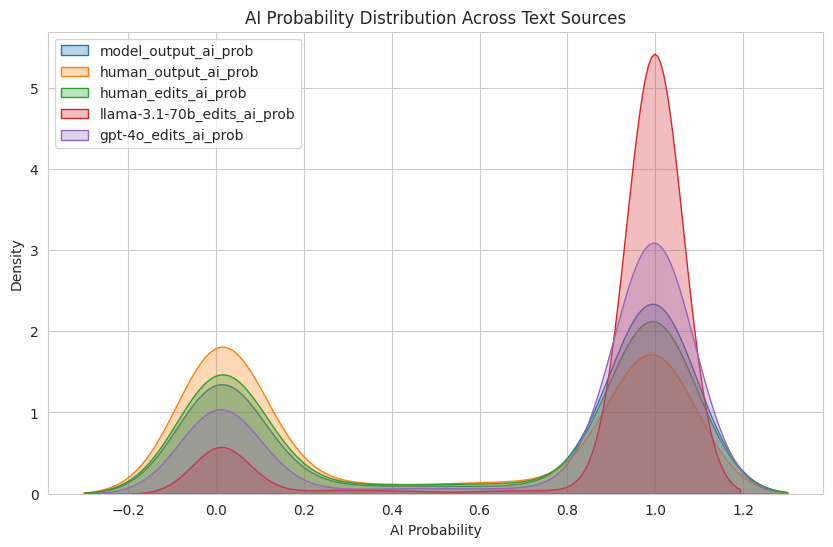

In [ ]:
prob_cols = [
    "model_output_ai_prob",
    "human_output_ai_prob",
    "human_edits_ai_prob",
    "llama-3.1-70b_edits_ai_prob",
    "gpt-4o_edits_ai_prob"
]

plt.figure(figsize=(10,6))

for col in prob_cols:
    sns.kdeplot(benchmark_df[col], label=col, fill=True, alpha=0.3)

plt.title("AI Probability Distribution Across Text Sources")
plt.xlabel("AI Probability")
plt.ylabel("Density")
plt.legend()
plt.show()

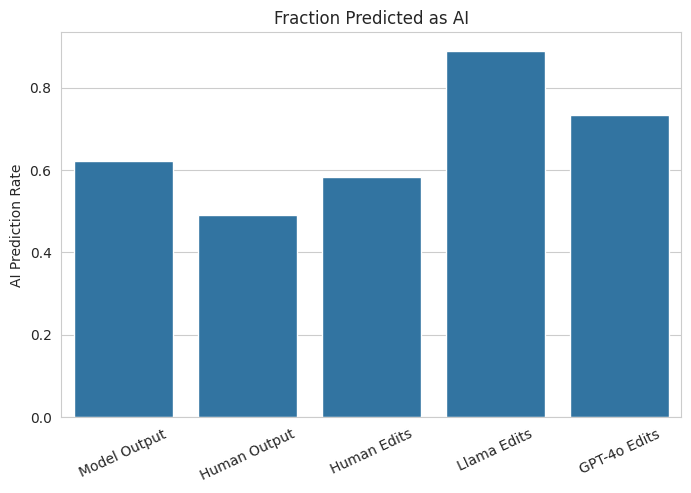

In [ ]:
pred_cols = [
    "model_output_pred",
    "human_output_pred",
    "human_edits_pred",
    "llama-3.1-70b_edits_pred",
    "gpt-4o_edits_pred"
]

ai_rates = [benchmark_df[c].mean() for c in pred_cols]

labels = [
    "Model Output",
    "Human Output",
    "Human Edits",
    "Llama Edits",
    "GPT-4o Edits"
]

plt.figure(figsize=(8,5))
sns.barplot(x=labels, y=ai_rates)

plt.title("Fraction Predicted as AI")
plt.ylabel("AI Prediction Rate")
plt.xticks(rotation=25)
plt.show()

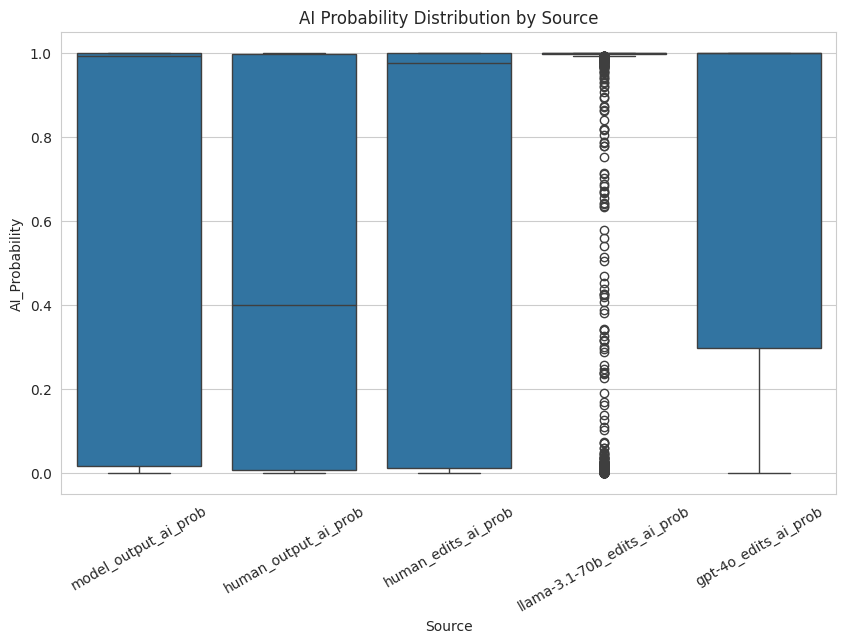

In [ ]:
plot_df = pd.melt(
    benchmark_df[prob_cols],
    var_name="Source",
    value_name="AI_Probability"
)

plt.figure(figsize=(10,6))

sns.boxplot(
    data=plot_df,
    x="Source",
    y="AI_Probability"
)

plt.xticks(rotation=30)
plt.title("AI Probability Distribution by Source")
plt.show()

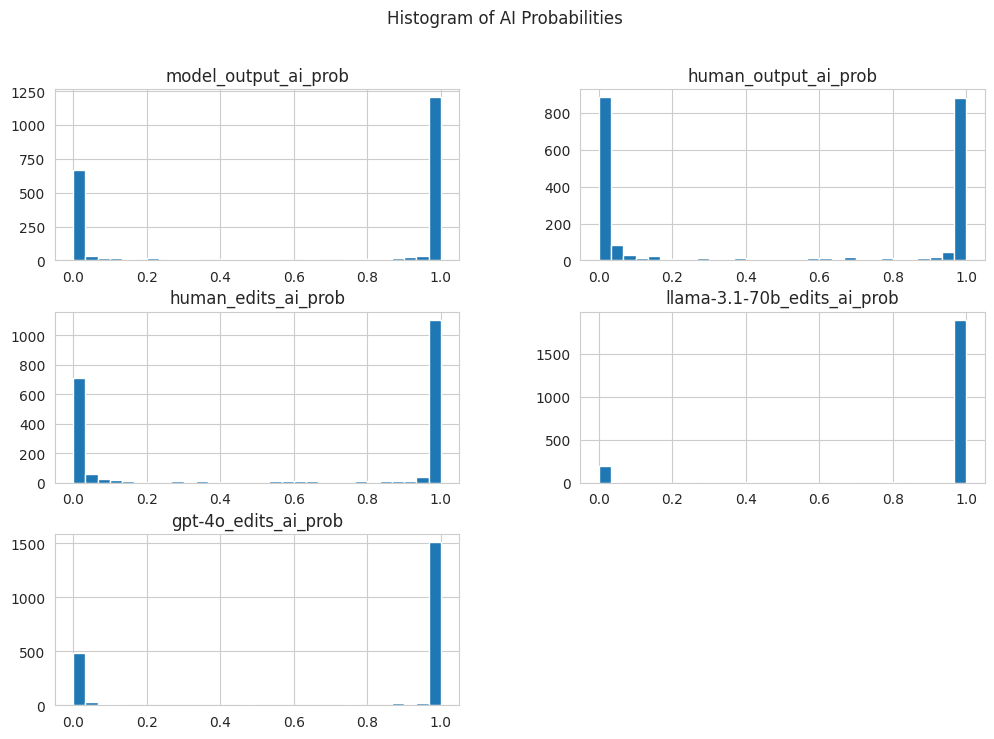

In [ ]:
benchmark_df[prob_cols].hist(
    figsize=(12,8),
    bins=30
)

plt.suptitle("Histogram of AI Probabilities")
plt.show()

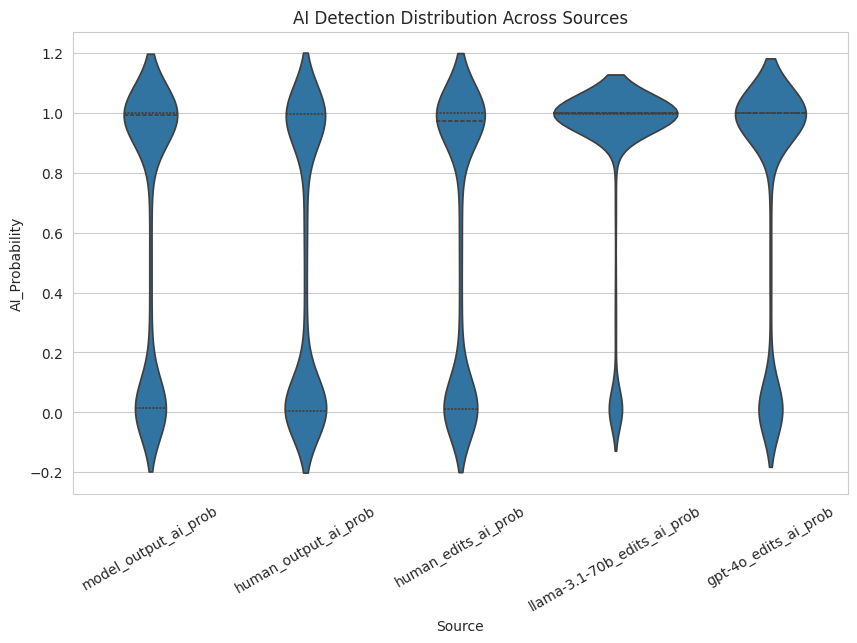

In [ ]:
plt.figure(figsize=(10,6))

sns.violinplot(
    data=plot_df,
    x="Source",
    y="AI_Probability",
    inner="quartile"
)

plt.xticks(rotation=30)
plt.title("AI Detection Distribution Across Sources")
plt.show()

In [ ]:
def predict_single(text):

    encoding = tokenizer(
        text,
        truncation=True,
        padding=True,
        max_length=350,
        return_tensors="pt"
    ).to(device)

    with torch.no_grad():
        outputs = model(**encoding)

    probs = torch.softmax(outputs.logits, dim=1)

    return probs.cpu().numpy()